# VEST 40326, 322 ms: validated equilibrium candidate and kinetic-state checks

The archived magnetic EFIT, `electron_efit`, Thomson channels, core profiles, and transient OpenADAS C/O composition are all time matched at 322 ms. The electron-kinetic EFIT **passes** the campaign admissibility gate. It nevertheless used the VEST fallback $T_i=T_e$, $n_i=n_e$ without impurity dilution. The equal elemental densities $n_C=n_O$ and $\langle Z_{\rm eff}\rangle_{n_e dV}=2$ are explicit assumptions applied here, not inputs to that EFIT fit.

Two distinct results are shown: (1) a C/O pressure partition on the independent magnetic EFIT, where $T_i$ may be inferred, and (2) an assumption-aware comparison of the fitted electron-kinetic EFIT, from which $T_i$ must **not** be inferred again. The figures use the public `vaft.plot` `Profile1D`/`Panels` view models with its default colour resolution.

In [ ]:
from pathlib import Path
import hashlib, json, warnings
import numpy as np
import matplotlib.pyplot as plt
import vaft
import vaft.omas
from vaft.plot import Panels, Profile1D, Series, render_panels
from vaft.validation.kinetic_state import infer_ti_pressure_partition

ROOT=Path.cwd()
if not (ROOT/'workflow'/'kinetic_state').exists(): ROOT=ROOT.parent
SNAPSHOT=ROOT/'workflow'/'kinetic_state'/'archive_data'/'vest_40326_322ms.json'
s=json.loads(SNAPSHOT.read_text())
assert (s['shot'],s['time_s'])==(40326,0.322)
print('Snapshot:',SNAPSHOT.relative_to(ROOT))
for name,item in s['provenance'].items(): print(name,item['sha256'])

Snapshot: workflow/kinetic_state/archive_data/vest_40326_322ms.json
magnetic_efit bc9a6b066211f7c40c54a801cfc00477eb6b1b123fb64a01166b81650b66f5c4
core_profiles ea74d135c2d6e315636373856e85479ecc31e1ff7caa0b16f1a34a7e5bdd032a
electron_efit 6b34711bb888f69ba635d1e5b64b193fc5a28c204acd0bf1b0037cc5b3342542
state_atlas d023ee87da53b7cf09a48a79663d2987f423bafe696099781a1b4100f202480a
state_profiles_atlas f2daafa6f89298115e40ed27ab163788667b3b246bd24779946f12d1dfa58cf9
impurity_states_atlas 5b64960c537fa79a0a8b7f6b44416b154254593d1b101bfba7f5e3e1d36f56e1
impurity_profiles_atlas 306b51bca4d4eaa7d6b7367640fb00d6222cdae27142efaa366c7566a0aa046b
electron_efit_manifest 661c787d6f0f392cc68adb9bb84cbd4bc22bdc0687c3b31310fb7835bd4d1f0c


## 1. Time, flux grids, and measured Thomson positions

Magnetic EFIT and `core_profiles` use the same grid. Kinetic EFIT has its own flux mapping. The two sets of Thomson points below are the **same physical channels** mapped through each equilibrium separately; neither set is silently placed on the other equilibrium's coordinate.

In [ ]:
E=1.602176634e-19
eq=s['magnetic_equilibrium']; kin=s['electron_kinetic_equilibrium']; cp=s['core_profiles']
ts_m=s['mapped_thomson']['magnetics'];ts_k=s['mapped_thomson']['electron_kinetic']
rho=np.asarray(cp['rho_tor_norm'],float);rho_k=np.asarray(kin['rho_tor_norm'],float)
ne=np.asarray(cp['electron_density_m3'],float);te=np.asarray(cp['electron_temperature_eV'],float)
peq=np.asarray(eq['pressure_Pa'],float);peq_k=np.asarray(kin['pressure_Pa'],float)
volume=np.asarray(eq['volume_m3'],float)
assert eq['time_s']==cp['time_s']==kin['time_s']==s['time_s']
np.testing.assert_allclose(rho,eq['rho_tor_norm'],rtol=0,atol=1e-10)
np.testing.assert_allclose(cp['psi_Wb'],eq['psi_Wb'],rtol=0,atol=1e-10)
assert len(rho)==len(rho_k)==129 and len(ts_m['rho_tor_norm'])==len(ts_k['rho_tor_norm'])==5
for key in ('electron_density_m3','electron_temperature_eV'):
    np.testing.assert_allclose(ts_m[key],ts_k[key],rtol=0,atol=0)
assert s['state_assessment']['electron_kinetic']['kinetic_admissible']=='pass'
assert np.min(peq_k)>=0
print('Time:',1000*s['time_s'],'ms; kinetic pressure minimum:',peq_k.min(),'Pa')
print('Maximum native rho-grid difference:',np.max(np.abs(rho_k-rho)))
print('Thomson mappings, magnetic:',np.round(ts_m['rho_tor_norm'],3))
print('Thomson mappings, kinetic: ',np.round(ts_k['rho_tor_norm'],3))

Time: 322.0 ms; kinetic pressure minimum: 1.08194241 Pa
Maximum native rho-grid difference: 0.0023924624677103545
Thomson mappings, magnetic: [0.3   0.135 0.046 0.283 0.476]
Thomson mappings, kinetic:  [0.291 0.127 0.058 0.288 0.478]


## 2. Transient C/O composition and pressure partition on magnetic EFIT

The snapshot stores charge fractions recalculated with VAFT's #1577 resolver and the product hashes. The common ion temperature is inferred from $p_{\rm eq}-p_e$ only on the magnetic lineage. Invalid pressure or charge-state points remain empty. The target $Z_{\rm eff}=2$ is an $n_e dV$-weighted mean, not a flat radial profile.

In [ ]:
a=s['openadas_charge_states']; m=s['impurity_model']
fC=np.asarray(a['C'],float);fO=np.asarray(a['O'],float)
qC=np.arange(7);qO=np.arange(9)
valid_charge=np.isfinite(fC).all(axis=1)&np.isfinite(fO).all(axis=1)
np.testing.assert_allclose(fC[valid_charge].sum(axis=1),1,atol=1e-12)
np.testing.assert_allclose(fO[valid_charge].sum(axis=1),1,atol=1e-12)
nC=nO=0.5*m['scale']*ne
nH=ne-nC*(fC@qC)-nO*(fO@qO)
nC_ion=nC*(1-fC[:,0]);nO_ion=nO*(1-fO[:,0])
nimp=nC_ion+nO_ion;nion=nH+nimp
zeff=(nH+nC*(fC@(qC*qC))+nO*(fO@(qO*qO)))/ne
edges=np.r_[0,.5*(rho[:-1]+rho[1:]),rho[-1]]
dV=np.clip(np.diff(np.interp(edges,rho,volume)),0,None)
np.testing.assert_allclose(ne[valid_charge],(nH+nC*(fC@qC)+nO*(fO@qO))[valid_charge],rtol=1e-12)
assert np.all(nH[valid_charge]>=0)
zeff_mean=np.nansum(ne*dV*zeff)/np.nansum(ne*dV)
np.testing.assert_allclose(zeff_mean,2,rtol=1e-12)
np.testing.assert_allclose(zeff[0],m['atlas_zeff_axis'],rtol=1e-12)
np.testing.assert_allclose(np.interp(.9,rho[valid_charge],zeff[valid_charge]),m['atlas_zeff_rho09'],rtol=1e-12)
pe=E*ne*te
Ti=np.full_like(rho,np.nan)
for j in np.flatnonzero(valid_charge):
    result=infer_ti_pressure_partition(peq[j],ne[j],te[j],
        composition={'ion_density_per_electron':nion[j]/ne[j],
                     'composition_source':'transient C/O, equal elemental densities, mean Zeff=2'},
        sigma_p_eq=np.nan,sigma_n_e=np.nan,sigma_t_e=np.nan,
        equilibrium_lineage='magnetics')
    assert result['eligible']
    Ti[j]=float(np.asarray(result['t_i']))
valid_ti=valid_charge&np.isfinite(Ti)&(nion>0)
pi=np.where(valid_ti,E*nion*Ti,np.nan)
pkin=pe+pi
np.testing.assert_allclose(pkin[valid_ti],peq[valid_ti],rtol=1e-12,atol=1e-12)
print('C/O composition: nC=nO; mean Zeff =',zeff_mean)
print('Physical magnetic-EFIT Ti grid points:',valid_ti.sum(),'/',len(rho))
print('Maximum pressure-closure residual:',np.nanmax(abs(pkin-peq)),'Pa (identity)')

C/O composition: nC=nO; mean Zeff = 2.0
Physical magnetic-EFIT Ti grid points: 117 / 129
Maximum pressure-closure residual: 5.684341886080802e-14 Pa (identity)


### Measured-channel alignment

Use the five Thomson channels at their **magnetic** mapping to evaluate the pressure residual with the C/O ion fraction. All five channel residuals are positive. This is a physical-positivity check; it does not supply an uncertainty for the inferred $T_i$ or turn the pressure closure into independent agreement.

In [ ]:
rt=np.asarray(ts_m['rho_tor_norm'],float)
ne_ts=np.asarray(ts_m['electron_density_m3'],float);te_ts=np.asarray(ts_m['electron_temperature_eV'],float)
sne_ts=np.asarray(ts_m['electron_density_error_m3'],float);ste_ts=np.asarray(ts_m['electron_temperature_error_eV'],float)
p_ts=E*ne_ts*te_ts
sp_ts=E*np.hypot(te_ts*sne_ts,ne_ts*ste_ts)
ni_fraction=np.interp(rt,rho[valid_charge],(nion/ne)[valid_charge])
p_eq_ts=np.asarray(ts_m['p_eq_Pa'],float)
Ti_ts=(p_eq_ts-p_ts)/(E*ne_ts*ni_fraction)
assert np.all(Ti_ts>0)
for j in range(len(rt)):
    print(f'channel {j}: rho={rt[j]:.3f}, p_eq-p_e={p_eq_ts[j]-p_ts[j]:.1f} Pa, '
          f'Ti(C/O)={Ti_ts[j]:.1f} eV')

channel 0: rho=0.300, p_eq-p_e=216.5 Pa, Ti(C/O)=90.7 eV
channel 1: rho=0.135, p_eq-p_e=149.0 Pa, Ti(C/O)=43.1 eV
channel 2: rho=0.046, p_eq-p_e=127.2 Pa, Ti(C/O)=33.5 eV
channel 3: rho=0.283, p_eq-p_e=155.1 Pa, Ti(C/O)=41.0 eV
channel 4: rho=0.476, p_eq-p_e=144.0 Pa, Ti(C/O)=47.9 eV


## 3. Four-profile magnetic closure

The four panels are drawn by the public plot `vaft.omas.plot_kinetic_overview_state` (issue #1837). The plot reads stored IMAS paths only, so the state computed above is first written into an ODS: `core_profiles` receives the C/O ion densities, the inferred $T_i$, $p_i$ and $Z_{\rm eff}$, and each quantity's provenance in its `*_fit.parameters` record (evidence role as `origin=...`, the equilibrium lineage and occurrence on the ion-temperature record, the $Z_{\rm eff}$ target on the `zeff` record; invalid $T_i$ points are NaN). The composition is written by VAFT's own writer (`populate_radial_impurity_profiles`) from the archived charge states, which fills the one point whose charge states are undefined; the comparison below is at the defined points. The archive converter (`workflow/kinetic_state/archive_to_ods.py`) does that from this snapshot with the same algebra as the cells above; the converter checks the written densities and $Z_{\rm eff}$ against this algebra, and the cell checks its arrays are this notebook's before drawing. The Thomson channels keep their archived radii and are mapped by the plot through the stored equilibrium; the 2-D flux map they are mapped through is synthetic, built so they land on their archived $\psi_N$ (the snapshot keeps the mapping, not the map), and the mapped radii are checked against the archive.

Each legend entry names the recorded role: fitted $n_e$, $T_e$; assumed ion densities and $Z_{\rm eff}$; inferred $T_i$ and $p_i$; the $p_e+p_i=p_{\rm eq}$ closure identity; Thomson points as fit input for the profiles and as independent validation of the magnetic equilibrium pressure. Measured points keep their 1σ error bars; the shaded band is the measured radial span, beyond which the profiles are extrapolated. The `slide` preset sets the 2×2 canvas and the `poster` preset the 4×1 one; colours come from the plot's own intent tokens.

In [ ]:
import sys

sys.path.insert(0, str(ROOT / "workflow" / "kinetic_state"))
from archive_to_ods import kinetic_state_case  # noqa: E402  snapshot -> stored kinetic state

state = kinetic_state_case(40326, "magnetics")
np.testing.assert_allclose(state.t_i, Ti, rtol=0, atol=0, equal_nan=True)
np.testing.assert_array_equal(state.valid_ti, valid_ti)
np.testing.assert_allclose(state.p_i, pi, rtol=0, atol=0, equal_nan=True)
np.testing.assert_allclose(state.zeff, zeff, rtol=0, atol=0, equal_nan=True)
np.testing.assert_allclose(state.n_h, nH, rtol=0, atol=0)
np.testing.assert_allclose(state.n_imp, nimp, rtol=0, atol=0)
mag_view = vaft.omas.extract_kinetic_overview_state(state.ods)
ts_mapped = [t for t in mag_view.models[0].series if "TS" in t.label][0]
np.testing.assert_allclose(np.sort(ts_mapped.x), np.sort(rt), rtol=0, atol=2e-4)
for panel in mag_view.models:
    for trace in panel.metadata["traces"]:
        print(f"{panel.metadata['panel']:12s} {trace['quantity']:15s} {trace['role']}")

pressure     p_eq            stored
pressure     p_e             stored
pressure     p_i             inferred
pressure     p_kin           closure identity
pressure     p_e_thomson     independent validation
density      n_e             fit
density      n_main_ion      assumed
density      n_impurity_ion  assumed
density      n_e_thomson     fit input
temperature  T_e             fit
temperature  T_i             inferred
temperature  T_e_thomson     fit input
zeff         Z_eff           assumed
zeff         Z_eff_reference assumed


### 2×2 magnetic closure

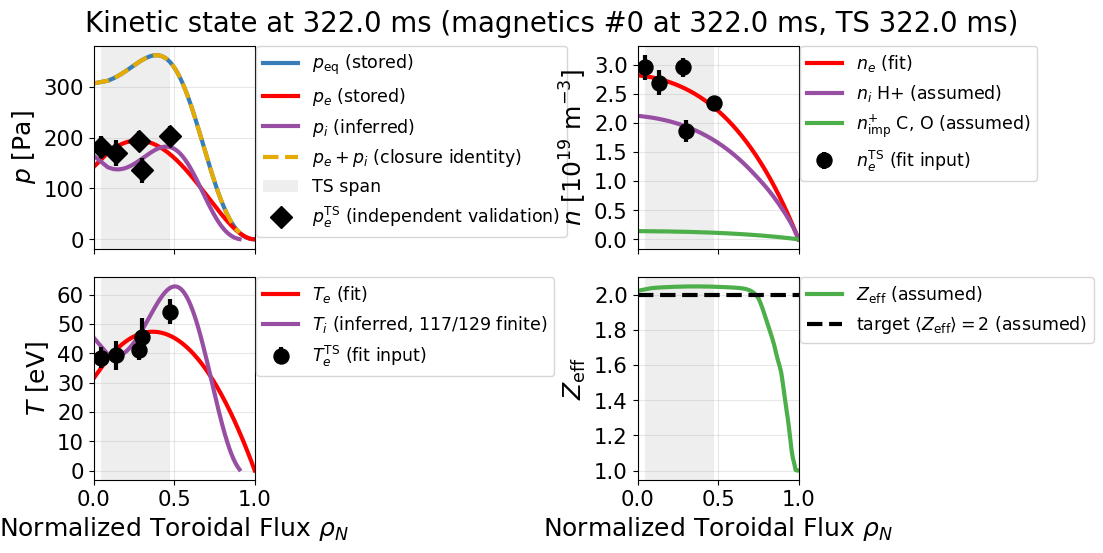

In [ ]:
fig_mag_grid, axes_mag_grid = vaft.omas.plot_kinetic_overview_state(state.ods, format="slide")
plt.show()

### 4×1 magnetic closure

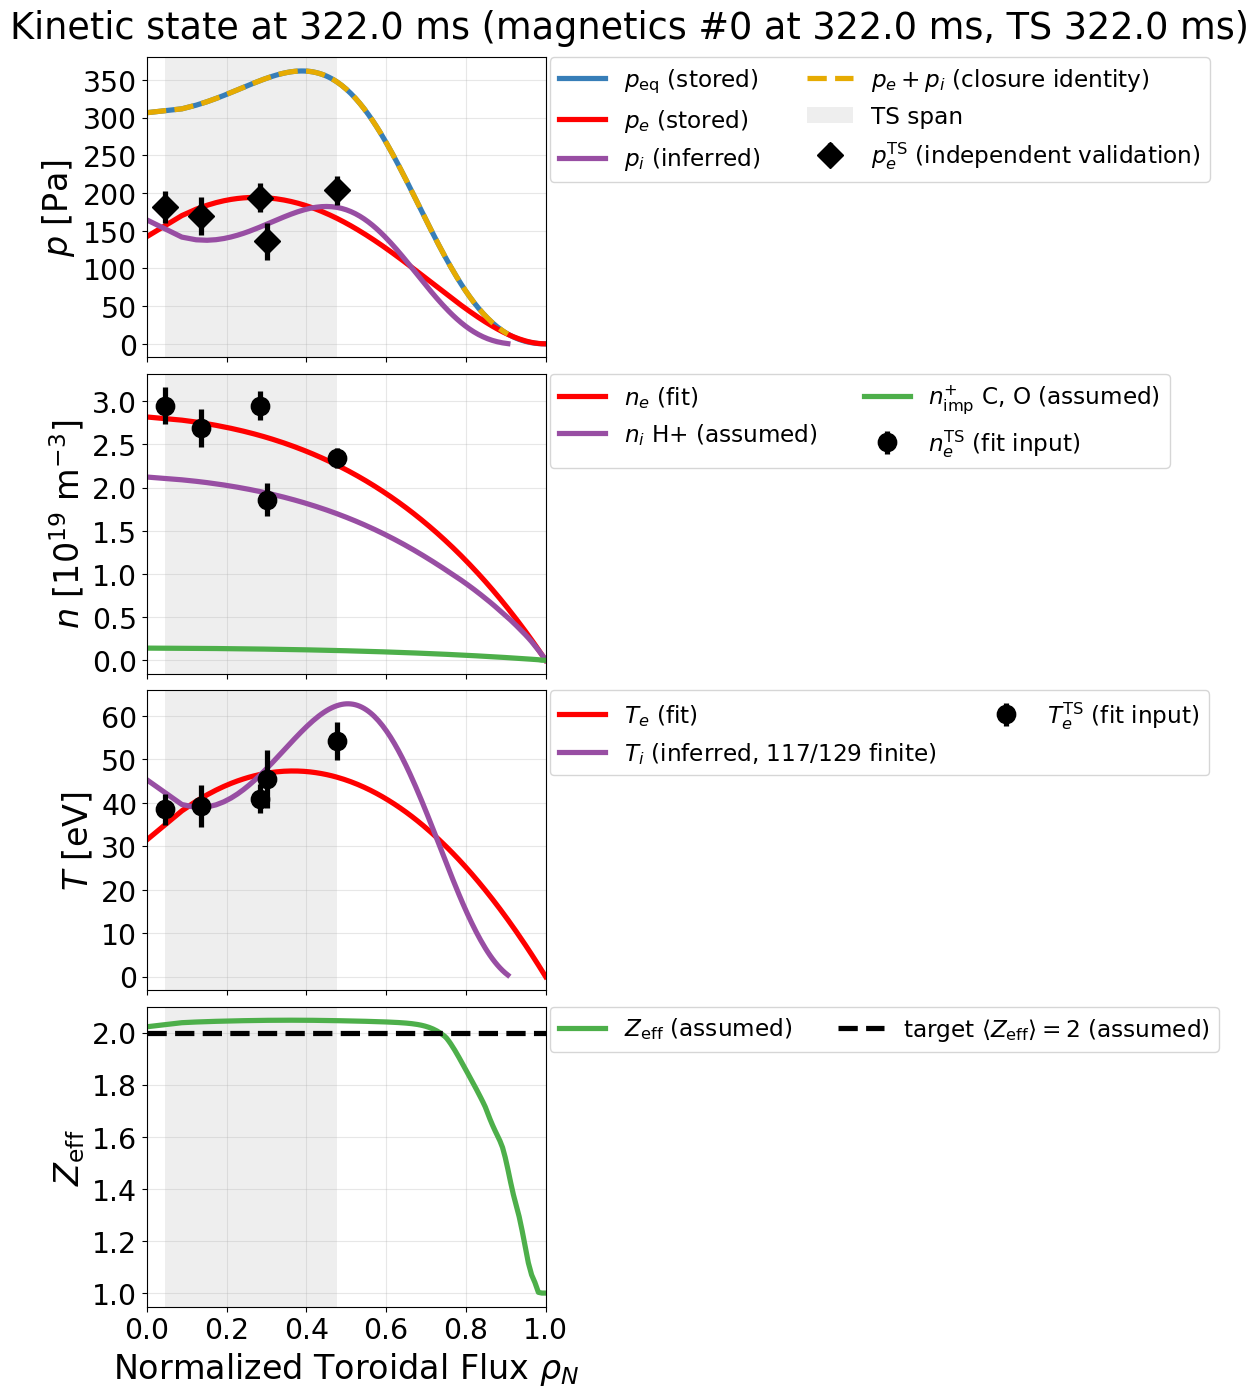

In [ ]:
fig_mag_stack, axes_mag_stack = vaft.omas.plot_kinetic_overview_state(state.ods, layout="stack", format="poster")
plt.show()

## 4. Electron-kinetic EFIT: accepted fit, different ion prior

The stored kinetic EFIT is admissible and its own mapping gives five matched Thomson channels. Its `raw6` pressure constraint used $p=2e n_eT_e$ at those channels, plus an edge anchor. The continuous $2p_e$ line is the *core_profiles* representation of that prior, not the actual six EFIT input points. The C/O $T_i=T_e$ pressure line is a counterfactual composition policy; it was **not** used in the fit. VAFT must refuse $T_i$ inference from this equilibrium because its pressure already depends on the $T_i/T_e$ assumption.

The fitted electron and C/O curves retain the magnetic `core_profiles` coordinate. Kinetic-EFIT Thomson markers use the kinetic mapping. Curves on different flux grids are compared by their normalized labels; this is not a pointwise spatial remapping of the fit.

The compact legends name the plotted quantities. This section records which pressure curves are EFIT results, which are assumed priors, and which are counterfactual C/O values.

In [ ]:
assessment=s['state_assessment']['electron_kinetic'];manifest=s['kinetic_manifest']
assert assessment['efit_status']=='valid' and assessment['kinetic_admissible']=='pass'
assert manifest['status']=='success' and manifest['converged'] and manifest['encoding']=='raw6'
assert assessment['ti_lineage']=='ti_eq_te_assumed' and float(assessment['ti_te_ratio_assumed'])==1
refused=infer_ti_pressure_partition(peq_k[0],ne[0],te[0],
 composition={'ion_density_per_electron':nion[0]/ne[0],'composition_source':'transient C/O'},
 sigma_p_eq=np.nan,sigma_n_e=np.nan,sigma_t_e=np.nan,equilibrium_lineage='electron_kinetic')
assert not refused['eligible'] and 'circular' in refused['reason']
rt_k=np.asarray(ts_k['rho_tor_norm'],float)
p_ts_k=E*np.asarray(ts_k['electron_density_m3'])*np.asarray(ts_k['electron_temperature_eV'])
np.testing.assert_allclose(p_ts,p_ts_k,rtol=1e-12)
p_input_ts=2*p_ts
sigma_ratio=.5
sp_input_ts=E*np.sqrt((2*te_ts*sne_ts)**2+(2*ne_ts*ste_ts)**2+(ne_ts*te_ts*sigma_ratio)**2)
p_prior_fit=2*pe
p_co_prior=pe+E*nion*te
print('Kinetic EFIT p_min:',peq_k.min(),'Pa; manifest chi2:',manifest['chi2'])
print('Pressure ratio r_w on magnetic pair span:',assessment['r_w_on_pair_span'],
      '; c_p:',assessment['c_p'])
print('VAFT inference guard:',refused['reason'])

Kinetic EFIT p_min: 1.08194241 Pa; manifest chi2: 361.7
Pressure ratio r_w on magnetic pair span: 1.9026945911314008 ; c_p: 0.00944033940242725
VAFT inference guard: circular: the 'electron_kinetic' equilibrium pressure was reconstructed with an assumed Ti/Te, so partitioning it returns that assumption


In [ ]:
from dataclasses import replace

def profile(x,y,label,*,color=None,ls='-',yerr=None,marker=None,mask=None):
    style={'linestyle':ls}
    if color is not None:style['color']=color
    if marker is not None:style['marker']=marker
    return Series(x=x,y=y,label=label,yerr=yerr,style=style,valid_mask=mask)

# The prior and counterfactual curves below are outside the stored kinetic state the
# public plot draws, so this comparison keeps its own panels; the shared Z_eff panel is
# the plot's own.
VAFT_COLORS = {
    'equilibrium': 'palette:0',
    'comparison': 'palette:7',
    'electron_fit': 'role:reconstructed',
    'ion': 'palette:2',
    'impurity': 'palette:3',
    'measurement': 'role:measured',
}
xlabel=mag_view.models[0].coordinate_label
kin_models=(
 Profile1D(series=(
    profile(rho_k,peq_k,r'$p_{\mathrm{eq}}^{\mathrm{kin}}$',color=VAFT_COLORS['equilibrium']),
    profile(rho,peq,r'$p_{\mathrm{eq}}^{\mathrm{mag}}$',color=VAFT_COLORS['comparison'],ls='--'),
    profile(rho,p_prior_fit,r'$2p_e$',color=VAFT_COLORS['electron_fit']),
    profile(rho,p_co_prior,r'$p_e+p_i$',color=VAFT_COLORS['ion'],ls='--',mask=valid_charge),
    profile(rt_k,p_input_ts,r'$2p_e^{\mathrm{TS}}\pm1\sigma$',color=VAFT_COLORS['measurement'],yerr=sp_input_ts,marker='D',ls='none')),
    coordinate_label=xlabel,y_label=r'$p$',y_unit='Pa',title='',x_limits=(0,1)),
 Profile1D(series=(
    profile(rho,ne/1e19,r'$n_e$',color=VAFT_COLORS['electron_fit']),
    profile(rho,nH/1e19,r'$n_{\mathrm{H}^+}$',color=VAFT_COLORS['ion'],mask=valid_charge),
    profile(rho,nimp/1e19,r'$n_{\mathrm{imp}}$',color=VAFT_COLORS['impurity'],mask=valid_charge),
    profile(rt_k,ne_ts/1e19,r'$n_e^{\mathrm{TS}}\pm1\sigma$',color=VAFT_COLORS['measurement'],
            yerr=sne_ts/1e19,marker='o',ls='none')),
    coordinate_label=xlabel,y_label=r'$n$',y_unit='10^19 m^-3',title='',x_limits=(0,1)),
 Profile1D(series=(
    profile(rho,te,r'$T_e$',color=VAFT_COLORS['electron_fit']),
    profile(rho,te,r'$T_i=T_e$',color=VAFT_COLORS['ion'],ls='--'),
    profile(rt_k,te_ts,r'$T_e^{\mathrm{TS}}\pm1\sigma$',color=VAFT_COLORS['measurement'],yerr=ste_ts,marker='o',ls='none')),
    coordinate_label=xlabel,y_label=r'$T$',y_unit='eV',title='',x_limits=(0,1)),
 replace(mag_view.models[3], reference_lines=()),  # the plot's Z_eff panel, unshaded
)
assert len(kin_models)==4

### 2×2 electron-kinetic EFIT check

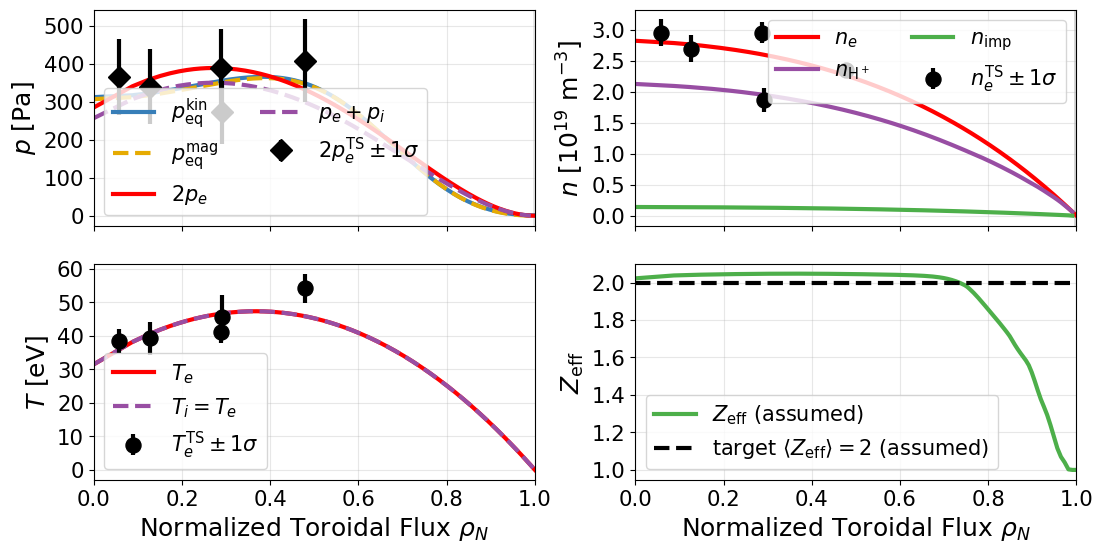

In [ ]:
fig_kin_grid,axes_kin_grid=render_panels(Panels(models=kin_models,nrows=2,ncols=2,share_x=True),
    format='slide')
for j,ax in enumerate(np.asarray(axes_kin_grid).flat):
    legend=ax.get_legend()
    if legend is not None:
        loc=('lower left','upper right','lower left','lower left')[j]
        if j in (0,1):
            ax.legend(loc=loc,ncol=2,prop=legend.prop)
        else:
            legend.set_loc(loc)
plt.show()

### 4×1 electron-kinetic EFIT check

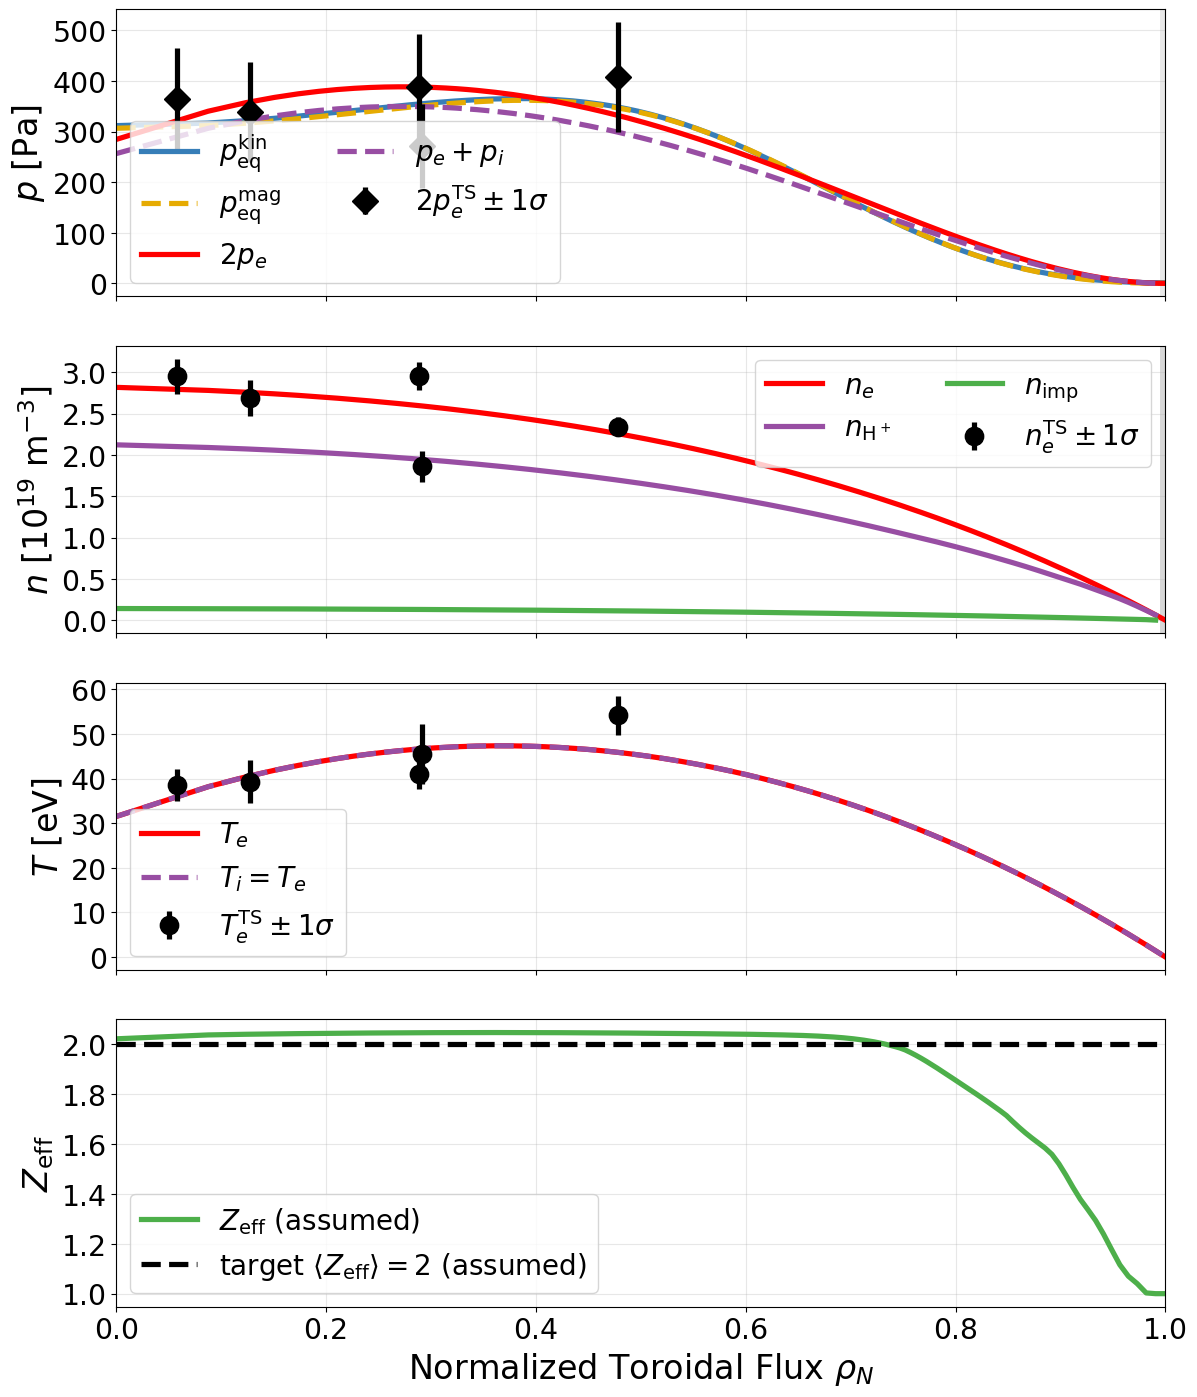

In [ ]:
fig_kin_stack,axes_kin_stack=render_panels(Panels(models=kin_models,nrows=4,ncols=1,share_x=True),
    format='poster')
for j,ax in enumerate(np.asarray(axes_kin_stack).flat):
    legend=ax.get_legend()
    if legend is not None:
        loc=('lower left','upper right','lower left','lower left')[j]
        if j in (0,1):
            ax.legend(loc=loc,ncol=2,prop=legend.prop)
        else:
            legend.set_loc(loc)
plt.show()

## Interpretation

- The magnetic EFIT and Thomson fit permit a C/O pressure-partition inference on 117/129 radial grid points. All five Thomson-channel pressure residuals are positive under this composition; $p_{\rm kin}=p_{\rm eq}$ remains an imposed closure.
- The electron-kinetic EFIT passes the campaign admissibility gate and has nonnegative stored pressure. Thomson was used to constrain it, so its alignment with Thomson is not independent validation.
- Its fit used $T_i=T_e$ and $n_i=n_e$. The equal C/O, mean-$Z_{\rm eff}=2$ state has lower charged-ion density and was **not** fed back into the EFIT solver. A fully C/O-constrained equilibrium still requires a new reconstruction and admissibility check.
- The plotted local $Z_{\rm eff}(\rho)$ and ion densities are model-derived from the assumed composition. There is no measured ion-temperature profile or direct impurity-profile diagnostic for this case.